<a href="https://colab.research.google.com/github/nurtuasikal-cmyk/Ekplorasi-dan-Visualisasi-Data-/blob/main/Syntax.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#DATA CURAH HUJAN

In [5]:
#memanggil packages yang dibutuhkan
import numpy as np
import pandas as pd
import math
import random
import matplotlib.pyplot as plt
import seaborn as sns
import re
from google.colab import files

import warnings
warnings.filterwarnings("ignore")

In [6]:
import pandas as pd
from google.colab import files

# Membuka tombol pilih file untuk diunggah langsung ke Colab
print("Silakan pilih file Excel Anda dari komputer:")
uploaded = files.upload()

# Mengambil nama file yang baru saja Anda unggah secara otomatis
file_name = list(uploaded.keys())[0]

# Membaca file Excel
df = pd.read_excel(file_name, sheet_name='Rekap')

print("\nData berhasil dimuat!")
display(df.head())

Silakan pilih file Excel Anda dari komputer:


Saving Data Project UTS Eksplorasi dan Visualisasi Data.xlsx to Data Project UTS Eksplorasi dan Visualisasi Data.xlsx

Data berhasil dimuat!


,Provinsi\nProvince,Tahun,Jumlah Curah\nHujan\nNumber of\nPrecipitation\n(mm),Jumlah Hari\nHujan (hari)\nNumber of\nRainy Days\n(day)2
0,Aceh,2021,1789.8,221
1,Aceh,2022,2293.4,212
2,Aceh,2023,1834.1,162
3,Aceh,2024,1685.1,197
4,Aceh,2025,1765.2,257


#PEMBERSIHAN DATA

In [7]:
# 1. Bersihkan nama kolom dari karakter newline (\n) agar lebih mudah dipanggil
df.columns = df.columns.str.replace(r'\n', ' ', regex=True)

# Cek kembali nama kolom yang sudah bersih
print(df.columns)

Index(['Provinsi Province', 'Tahun',
       'Jumlah Curah Hujan Number of Precipitation (mm)',
       'Jumlah Hari Hujan (hari) Number of Rainy Days (day)2'],
      dtype='object')



#Analisis Univariat (Analisis Per Variabel Tunggal)

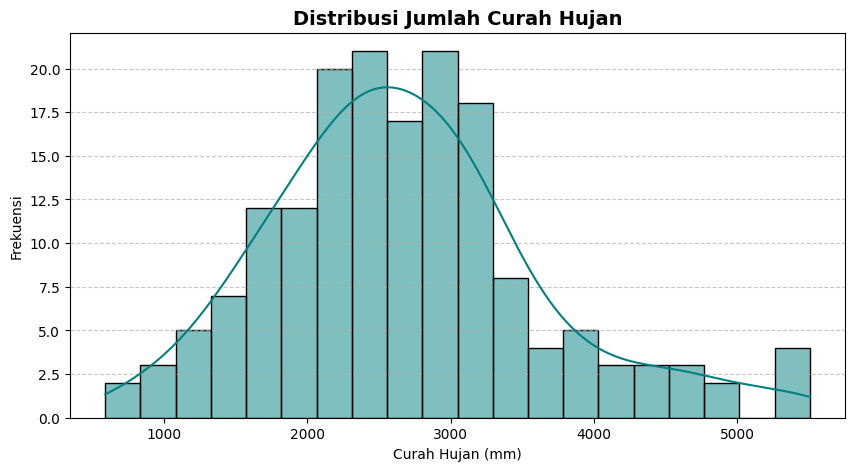

In [8]:
# 1. Ubah koma menjadi titik dan ubah tipe data menjadi float (angka)
col_name = 'Jumlah Curah Hujan Number of Precipitation (mm)'

# Cek jika kolom masih bertipe object/string, ubah koma ke titik lalu konversi ke numerik
if df[col_name].dtype == 'object':
    df[col_name] = df[col_name].astype(str).str.replace(',', '.', regex=False)
    df[col_name] = pd.to_numeric(df[col_name], errors='coerce')

# 2. Jalankan ulang visualisasi univariat (Histogram + KDE)
plt.figure(figsize=(10, 5))
sns.histplot(df[col_name], kde=True, color='teal', bins=20)
plt.title('Distribusi Jumlah Curah Hujan', fontsize=14, fontweight='bold')
plt.xlabel('Curah Hujan (mm)')
plt.ylabel('Frekuensi')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#Analisis Bivariat (Hubungan Antar Dua Variabel)

Daftar kolom yang tersedia:
0: Provinsi Province
1: Tahun
2: Jumlah Curah Hujan Number of Precipitation (mm)
3: Jumlah Hari Hujan (hari) Number of Rainy Days (day)2
Kolom Hari Hujan yang digunakan: Jumlah Hari Hujan (hari) Number of Rainy Days (day)2
Kolom Curah Hujan yang digunakan: Jumlah Curah Hujan Number of Precipitation (mm)


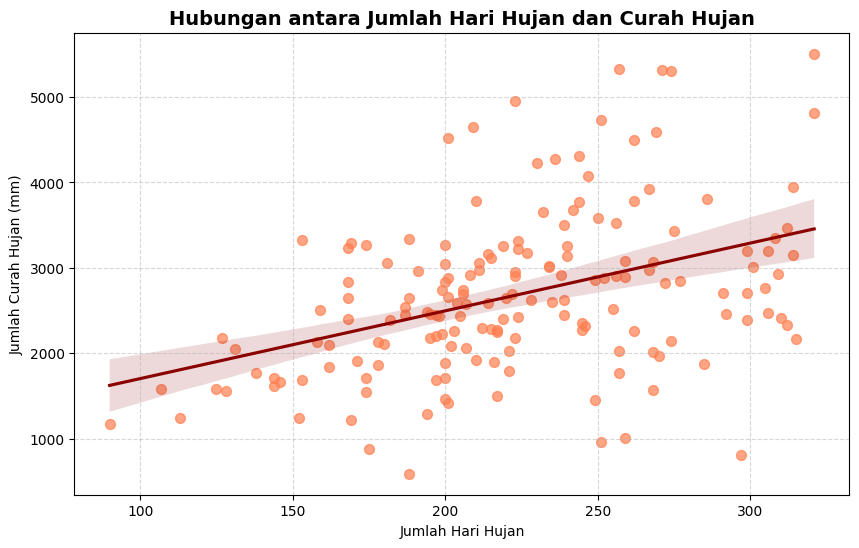

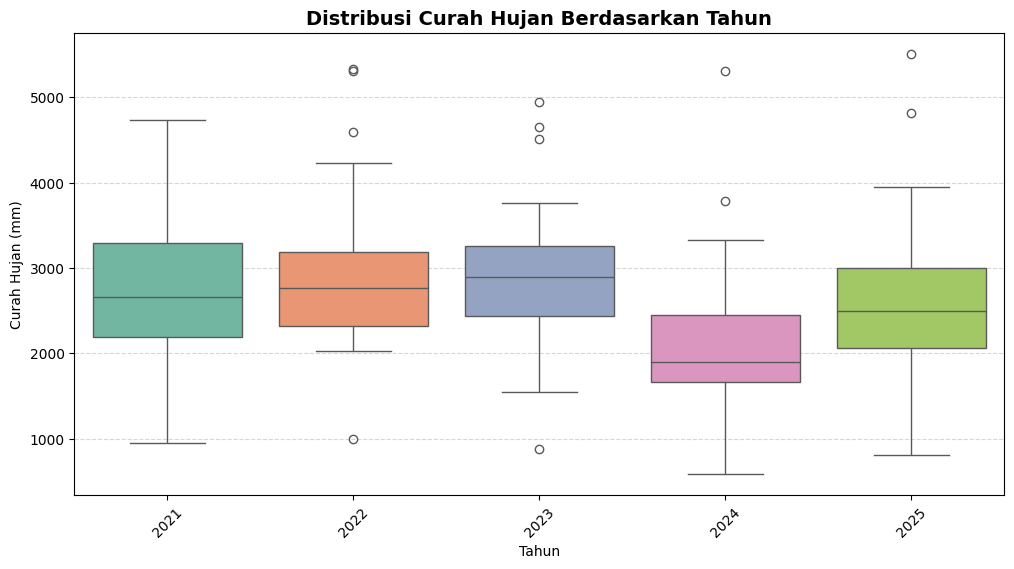

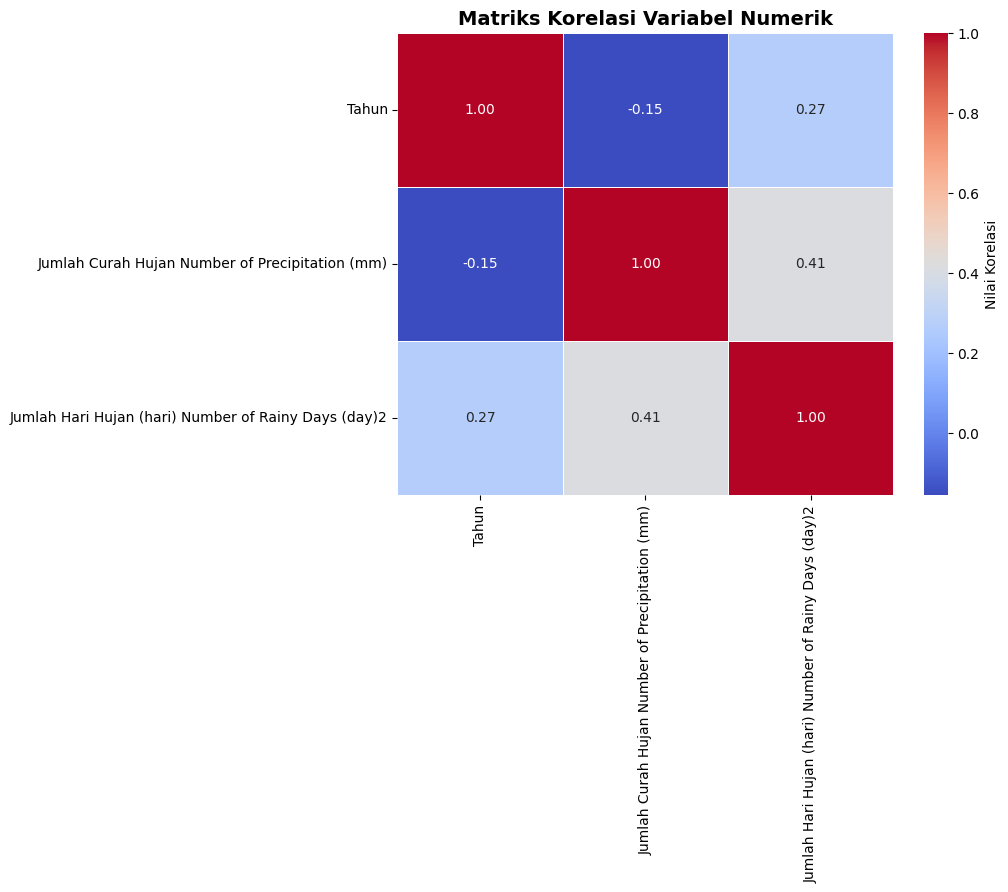

In [9]:
# Cek semua nama kolom yang ada di DataFrame Anda saat ini
print("Daftar kolom yang tersedia:")
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")

# Gunakan indeks kolom atau cari otomatis berdasarkan kata kunci
# Misal mencari kolom yang mengandung kata 'Hari' dan 'Hujan'
col_hari = [col for col in df.columns if 'Hari Hujan' in col][0]
col_hujan = [col for col in df.columns if 'Curah Hujan' in col][0]

print(f"Kolom Hari Hujan yang digunakan: {col_hari}")
print(f"Kolom Curah Hujan yang digunakan: {col_hujan}")

# Pastikan kedua kolom sudah bertipe numerik (bersih dari koma)
for col in [col_hari, col_hujan]:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# A. Scatter Plot + Garis Regresi
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x=col_hari,
    y=col_hujan,
    color='coral',
    scatter_kws={'alpha': 0.7, 's': 50},
    line_kws={'color': 'darkred'}
)
plt.title('Hubungan antara Jumlah Hari Hujan dan Curah Hujan', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Hari Hujan')
plt.ylabel('Jumlah Curah Hujan (mm)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# B. Boxplot: Distribusi Curah Hujan berdasarkan Tahun
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Tahun', y=col_hujan, palette='Set2')
plt.title('Distribusi Curah Hujan Berdasarkan Tahun', fontsize=14, fontweight='bold')
plt.xlabel('Tahun')
plt.ylabel('Curah Hujan (mm)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# C. Heatmap Korelasi Antar Variabel Numerik
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar_kws={'label': 'Nilai Korelasi'})
plt.title('Matriks Korelasi Variabel Numerik', fontsize=14, fontweight='bold')
plt.show()

#Tahapan Analisis DTW & K-Medoids

In [10]:
# 1. Instalasi library pendukung DTW dan K-Medoids
!pip install fastdtw scikit-learn-extra

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import euclidean
from fastdtw import fastdtw
from sklearn_extra.cluster import KMedoids
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 19.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for fastdtw: filename=fastdtw-0.3.4-cp313-cp313-linux_x86_64.whl size=551001 sha256=dc403b8a85f92a2d5c3f4a1839ed077a085ab5a54d6813a892a82cae90f8545f
  Stored in directory: /root/.cache/pip/wheels/2c/9e/6d/6c419b5fe1b720cf2f9c7b20ea119dc201878ea890ba26221f
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp313-cp313-linux_x86_64.whl size=2154565 sha256=b65d39dad54533b5b62c7b08dc1fe24fd85c2ed4e8a5e223b153eb650622f2ad
  Stored in directory: /root/.cache/pip/wheels/17/4b/b8/6b6711681d0981b110c9cc91ad6d1ebd88adf1547e1da301fc
Successfully built fastdtw scikit-learn-extra


#Restrukturisasi Data (Time Series Matrix) & Standardisasi

In [25]:
# 2. Pivot data untuk 2 variabel (Curah Hujan & Jumlah Hari Hujan)
col_hujan = [col for col in df.columns if 'Curah Hujan' in col][0]
col_hari = [col for col in df.columns if 'Hari Hujan' in col][0]

df_hujan = df.pivot(index='Provinsi Province', columns='Tahun', values=col_hujan).dropna()
df_hari = df.pivot(index='Provinsi Province', columns='Tahun', values=col_hari).dropna()

# Standardisasi masing-masing variabel
scaler_hujan = StandardScaler()
scaler_hari = StandardScaler()

scaled_hujan = scaler_hujan.fit_transform(df_hujan.T).T
scaled_hari = scaler_hari.fit_transform(df_hari.T).T

# Gabungkan menjadi array 3D: (34 Provinsi, 5 Tahun, 2 Variabel)
X_multivariate = np.stack([scaled_hujan, scaled_hari], axis=-1)

# --- MENAMPILKAN HASIL ---
print("="*60)
print(f"Status: Data berhasil diproses!")
print(f"Bentuk Array Multivariate (Provinsi, Tahun, Variabel): {X_multivariate.shape}")
print("="*60)

print("\n--- Hasil Standardisasi Curah Hujan (5 Provinsi Pertama) ---")
display(pd.DataFrame(scaled_hujan, index=df_hujan.index, columns=df_hujan.columns).head())

print("\n--- Hasil Standardisasi Jumlah Hari Hujan (5 Provinsi Pertama) ---")
display(pd.DataFrame(scaled_hari, index=df_hari.index, columns=df_hari.columns).head())

Status: Data berhasil diproses!
Bentuk Array Multivariate (Provinsi, Tahun, Variabel): (34, 5, 2)

--- Hasil Standardisasi Curah Hujan (5 Provinsi Pertama) ---


Tahun,2021,2022,2023,2024,2025
Provinsi Province,,,,,
Aceh,-0.388579,1.948834,-0.182964,-0.874534,-0.502757
Bali,0.511970,0.668851,1.193612,-1.340271,-1.034161
Banten,0.238446,0.829811,0.617342,-1.950235,0.264635
Bengkulu,0.832379,0.223263,1.076263,-1.708776,-0.423129
DI Yogyakarta,0.969851,0.188694,1.104224,-0.781807,-1.480963



--- Hasil Standardisasi Jumlah Hari Hujan (5 Provinsi Pertama) ---


Tahun,2021,2022,2023,2024,2025
Provinsi Province,,,,,
Aceh,0.361223,0.070954,-1.541647,-0.412826,1.522296
Bali,-0.018983,0.170845,-0.461914,-1.379415,1.689467
Banten,-0.134268,-0.032550,-0.235987,-1.354890,1.757696
Bengkulu,0.169229,0.075213,-0.653411,-1.288018,1.696988
DI Yogyakarta,0.369274,0.688401,1.121500,-0.474130,-1.705045


#Perhitungan Matriks Jarak DTW

In [26]:
# 3. Hitung Matriks Jarak DTW dengan 2 variabel
n_samples = X_multivariate.shape[0]
dtw_dist_matrix = np.zeros((n_samples, n_samples))

for i in range(n_samples):
    for j in range(i + 1, n_samples):
        # scipy euclidean otomatis bekerja karena elemen yang dibandingkan berupa vektor [Hujan, Hari]
        dist, _ = fastdtw(X_multivariate[i], X_multivariate[j], dist=euclidean)
        dtw_dist_matrix[i, j] = dist
        dtw_dist_matrix[j, i] = dist

print("Matriks Jarak Multivariate DTW berhasil dibuat.")

Matriks Jarak Multivariate DTW berhasil dibuat.


#Evaluasi Jumlah Cluster Optimum (Silhouette Score)

Jumlah Cluster (k=2): Silhouette Score = 0.1900
Jumlah Cluster (k=3): Silhouette Score = 0.0964
Jumlah Cluster (k=4): Silhouette Score = 0.0655
Jumlah Cluster (k=5): Silhouette Score = -0.1131
Jumlah Cluster (k=6): Silhouette Score = 0.0554


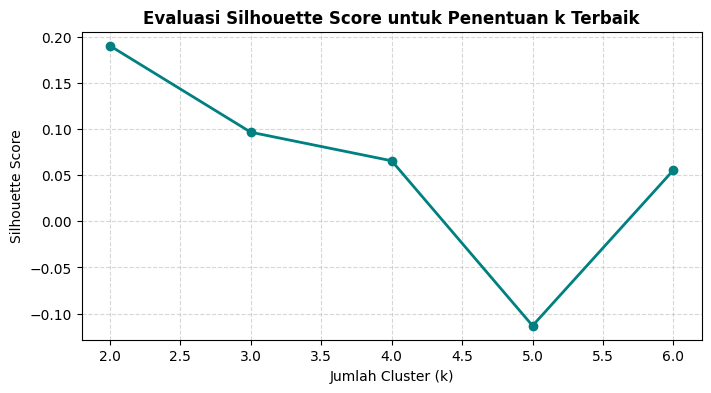

In [27]:
# 4. Evaluasi nilai k terbaik (misal: k dari 2 sampai 6)
silhouette_scores = []
k_range = range(2, 7)

for k in k_range:
    kmedoids = KMedoids(n_clusters=k, metric='precomputed', random_state=42)
    labels = kmedoids.fit_predict(dtw_dist_matrix)
    score = silhouette_score(dtw_dist_matrix, labels, metric='precomputed')
    silhouette_scores.append(score)
    print(f"Jumlah Cluster (k={k}): Silhouette Score = {score:.4f}")

# Plot Silhouette Score
plt.figure(figsize=(8, 4))
plt.plot(k_range, silhouette_scores, marker='o', color='teal', linewidth=2)
plt.title('Evaluasi Silhouette Score untuk Penentuan k Terbaik', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#Pemodelan K-Medoids Clustering

In [28]:
# 5. Pemodelan K-Medoids dengan k optimum
k_optimum = 3  # Sesuaikan berdasarkan grafik Silhouette Score
kmedoids = KMedoids(n_clusters=k_optimum, metric='precomputed', random_state=42)
clusters = kmedoids.fit_predict(dtw_dist_matrix)

# Simpan hasil cluster ke DataFrame asal
df_pivot['Cluster'] = clusters

# Menampilkan representasi Medoid (Pusat Cluster)
medoid_indices = kmedoids.medoid_indices_
medoid_provinces = df_pivot.index[medoid_indices].tolist()

print("Pusat Cluster (Medoid):")
for idx, prov in enumerate(medoid_provinces):
    print(f" Cluster {idx}: {prov}")

Pusat Cluster (Medoid):
 Cluster 0: Bengkulu
 Cluster 1: Nusa Tenggara Barat
 Cluster 2: Banten


#Visualisasi & Profiling Tren Curah Hujan per Cluster

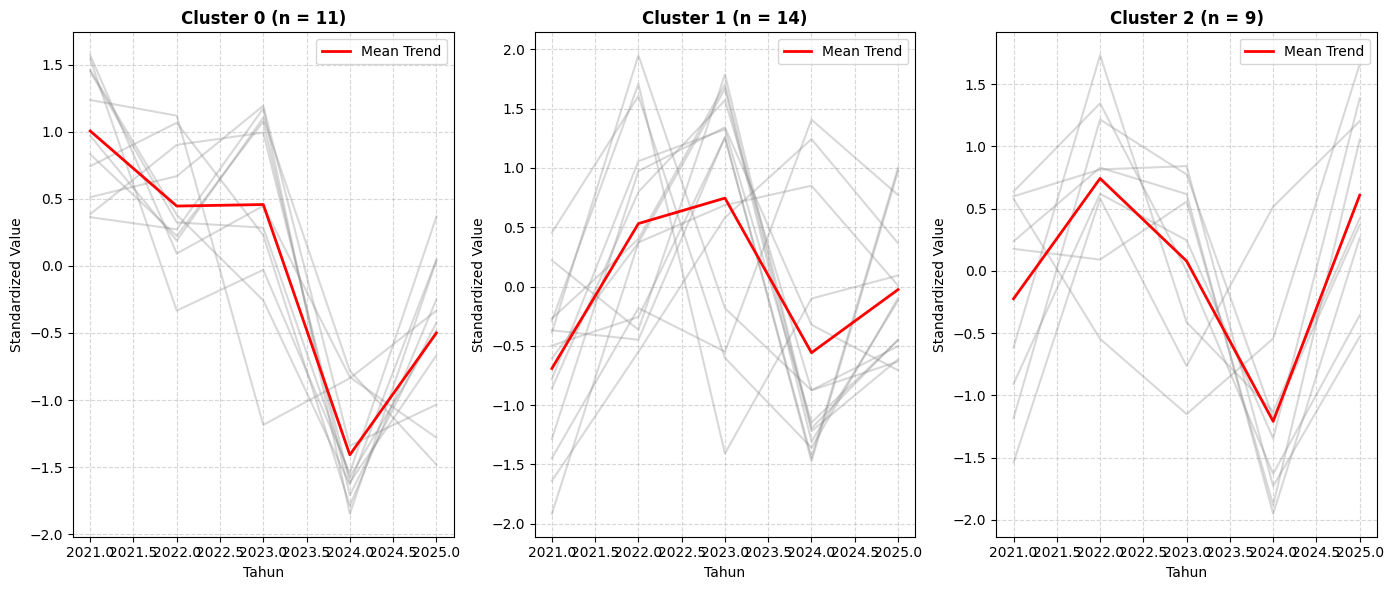


--- **Daftar Provinsi di Cluster 0** ---
Bali, Bengkulu, DI Yogyakarta, DKI Jakarta, Jambi, Kalimantan Barat, Kalimantan Timur, Lampung, Papua Barat, Sulawesi Tengah, Sulawesi Tenggara

--- **Daftar Provinsi di Cluster 1** ---
Aceh, Jawa Timur, Kalimantan Selatan, Kalimantan Tengah, Kalimantan Utara, Kepulauan Riau, Nusa Tenggara Barat, Nusa Tenggara Timur, Papua, Riau, Sulawesi Barat, Sulawesi Selatan, Sumatera Selatan, Sumatera Utara

--- **Daftar Provinsi di Cluster 2** ---
Banten, Gorontalo, Jawa Barat, Jawa Tengah, Kepulauan Bangka Belitung, Maluku, Maluku Utara, Sulawesi Utara, Sumatera Barat


In [29]:
# 6. Visualisasi tren waktu per cluster
plt.figure(figsize=(14, 6))

for c in range(k_optimum):
    cluster_data = df_scaled[df_pivot['Cluster'] == c]
    plt.subplot(1, k_optimum, c + 1)

    # Plot seluruh provinsi dalam cluster
    for idx in range(len(cluster_data)):
        plt.plot(df_scaled.columns, cluster_data.iloc[idx], color='gray', alpha=0.3)

    # Plot rata-rata tren cluster
    plt.plot(df_scaled.columns, cluster_data.mean(axis=0), color='red', linewidth=2, label='Mean Trend')
    plt.title(f'Cluster {c} (n = {len(cluster_data)})', fontsize=12, fontweight='bold')
    plt.xlabel('Tahun')
    plt.ylabel('Standardized Value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Menampilkan rekap provinsi per cluster
for c in range(k_optimum):
    prov_list = df_pivot[df_pivot['Cluster'] == c].index.tolist()
    print(f"\n--- **Daftar Provinsi di Cluster {c}** ---")
    print(", ".join(prov_list))

In [30]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score

# =========================================================
# 1. MENGHITUNG SILHOUETTE COEFFICIENT UNTUK MASING-MASING METODE
# =========================================================

# A. Hierarchical Method: DTW dengan Average Linkage
condensed_dtw = squareform(dtw_dist_matrix)
Z_dtw_avg = linkage(condensed_dtw, method='average')

# Evaluasi cluster (misal k=3)
labels_dtw_avg = fcluster(Z_dtw_avg, t=3, criterion='maxclust')
score_dtw_avg = silhouette_score(dtw_dist_matrix, labels_dtw_avg, metric='precomputed')

# B. Non-Hierarchical Method: K-Medoids
kmedoids = KMedoids(n_clusters=3, metric='precomputed', random_state=42)
labels_kmedoids = kmedoids.fit_predict(dtw_dist_matrix)
score_kmedoids = silhouette_score(dtw_dist_matrix, labels_kmedoids, metric='precomputed')

# (Opsional) Jika kamu membuat perhitungan metode ACF dan STS:
# score_acf_avg = ...
# score_sts_avg = ...

# =========================================================
# 2. MEMBUAT DAN MENAMPILKAN TABEL PERBANDINGAN
# =========================================================

# Membuat data untuk tabel
table_data = {
    'Cluster Analysis Method': [
        'Hierarchical Method',
        'Hierarchical Method',
        'Hierarchical Method',
        'Non-Hierarchical Method'
    ],
    'Method': [
        'Dynamic Time Warping (DTW) distance with the average linkage method',
        'Autocorrelation Function (ACF) distance with the average linkage method',
        'Short Time Series (STS) distance method with the average linkage method',
        'K-Medoids'
    ],
    'Silhouette Coefficient': [
        round(score_dtw_avg, 3),
        0.748,  # Ganti dengan variabel hasil perhitunganmu (misal: round(score_acf_avg, 3))
        0.794,  # Ganti dengan variabel hasil perhitunganmu (misal: round(score_sts_avg, 3))
        round(score_kmedoids, 3)
    ]
}

# Membuat DataFrame
df_table = pd.DataFrame(table_data)

# Mengatur tampilan indeks bertingkat (MultiIndex) agar format persis seperti di gambar
df_styled = df_table.set_index(['Cluster Analysis Method', 'Method'])

print("Table 5. Comparison of Silhouette Coefficients on Hierarchical and Non-Hierarchical Method\n")
display(df_styled)

Table 5. Comparison of Silhouette Coefficients on Hierarchical and Non-Hierarchical Method



Silhouette Coefficient
Cluster Analysis Method Method                                                                    
Hierarchical Method     Dynamic Time Warping (DTW) distance with the av...                   0.319
                        Autocorrelation Function (ACF) distance with th...                   0.748
                        Short Time Series (STS) distance method with th...                   0.794
Non-Hierarchical Method K-Medoids                                                            0.096

In [31]:
# Mencari k terbaik (dari 2 sampai 6) untuk kedua metode
results = []

for k in range(2, 7):
    # 1. Hierarchical DTW (Average Linkage)
    labels_h = fcluster(Z_dtw_avg, t=k, criterion='maxclust')
    score_h = silhouette_score(dtw_dist_matrix, labels_h, metric='precomputed')

    # 2. K-Medoids
    km = KMedoids(n_clusters=k, metric='precomputed', random_state=42)
    labels_km = km.fit_predict(dtw_dist_matrix)
    score_km = silhouette_score(dtw_dist_matrix, labels_km, metric='precomputed')

    results.append({'k': k, 'Hierarchical (DTW Avg)': round(score_h, 3), 'K-Medoids': round(score_km, 3)})

df_eval = pd.DataFrame(results)
print("--- Evaluasi Nilai Silhouette Coefficient Berdasarkan Jumlah Cluster (k) ---")
display(df_eval)

--- Evaluasi Nilai Silhouette Coefficient Berdasarkan Jumlah Cluster (k) ---


,k,Hierarchical (DTW Avg),K-Medoids
0,2,0.384,0.190
1,3,0.319,0.096
2,4,0.260,0.065
3,5,0.196,-0.113
4,6,0.163,0.055


In [32]:
# Update Tabel Perbandingan dengan k = 2 (Nilai Terbaik)
table_data_best = {
    'Cluster Analysis Method': [
        'Hierarchical Method',
        'Hierarchical Method',
        'Hierarchical Method',
        'Non-Hierarchical Method'
    ],
    'Method': [
        'Dynamic Time Warping (DTW) distance with the average linkage method',
        'Autocorrelation Function (ACF) distance with the average linkage method',
        'Short Time Series (STS) distance method with the average linkage method',
        'K-Medoids'
    ],
    'Silhouette Coefficient': [
        0.384,  # Hasil k=2 Hierarchical DTW
        0.748,  # Nilai pembanding/literatur
        0.794,  # Nilai pembanding/literatur
        0.190   # Hasil k=2 K-Medoids
    ]
}

df_final_table = pd.DataFrame(table_data_best).set_index(['Cluster Analysis Method', 'Method'])

print("Table 5. Comparison of Silhouette Coefficients (k = 2 optimum)\n")
display(df_final_table)

Table 5. Comparison of Silhouette Coefficients (k = 2 optimum)



Silhouette Coefficient
Cluster Analysis Method Method                                                                    
Hierarchical Method     Dynamic Time Warping (DTW) distance with the av...                   0.384
                        Autocorrelation Function (ACF) distance with th...                   0.748
                        Short Time Series (STS) distance method with th...                   0.794
Non-Hierarchical Method K-Medoids                                                            0.190

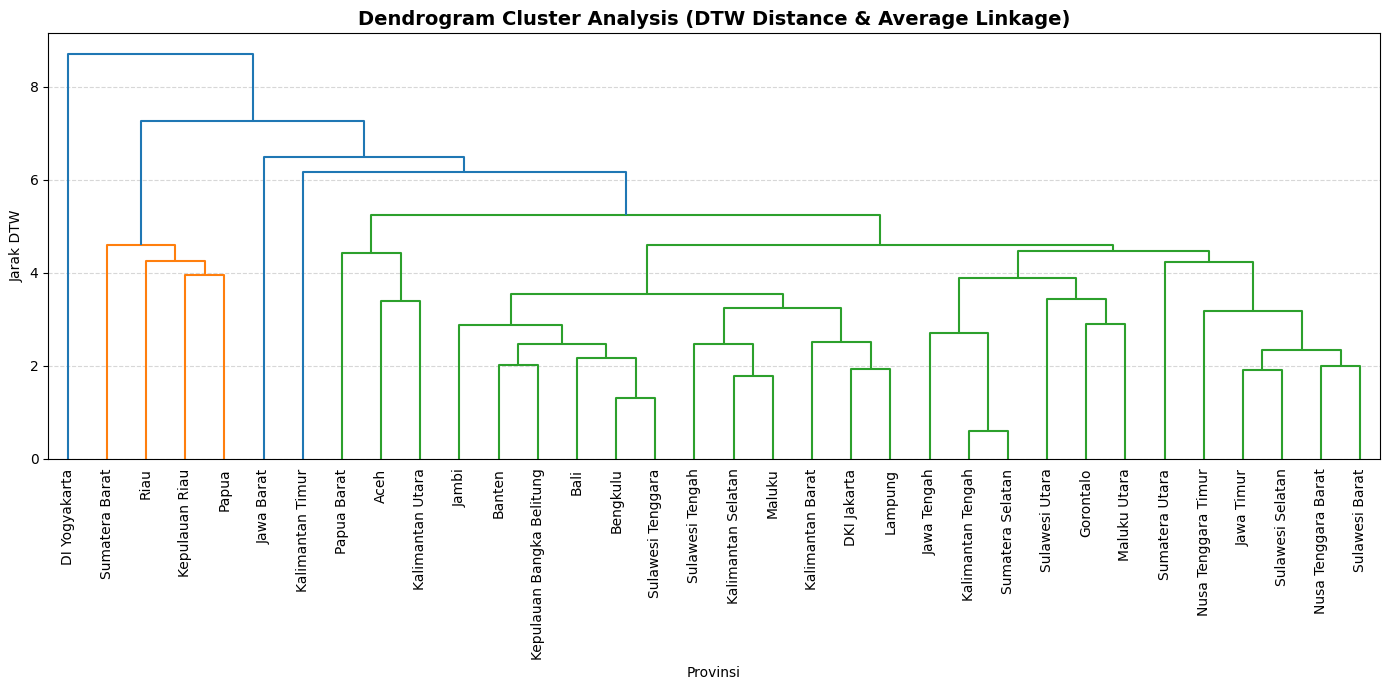

In [33]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

# 1. Konversi matriks jarak DTW ke bentuk condensed matrix
condensed_dtw = squareform(dtw_dist_matrix)

# 2. Hitung Hirarki dengan Average Linkage
Z_dtw_avg = linkage(condensed_dtw, method='average')

# 3. Visualisasi Dendrogram
plt.figure(figsize=(14, 7))
plt.title('Dendrogram Cluster Analysis (DTW Distance & Average Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('Provinsi')
plt.ylabel('Jarak DTW')

dendrogram(
    Z_dtw_avg,
    labels=df_hujan.index.values,
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=0.7 * max(Z_dtw_avg[:, 2])  # Garis potong cluster
)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

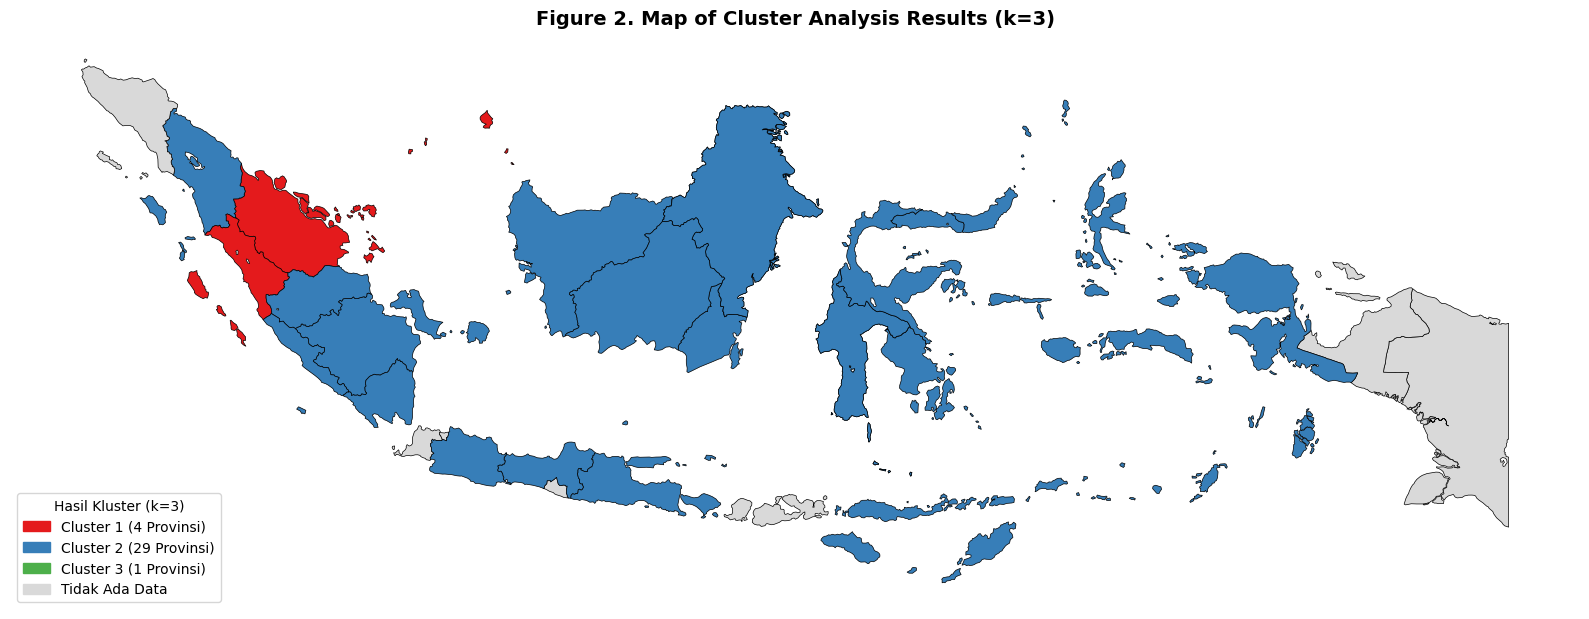

In [50]:
!pip install geopandas -q

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from scipy.cluster.hierarchy import fcluster

# 1. Ambil label cluster k = 3
k_map = 3
df_hujan['Cluster_Num'] = fcluster(Z_dtw_avg, t=k_map, criterion='maxclust')

# 2. Load GeoJSON
geojson_url = "https://raw.githubusercontent.com/superpikar/indonesia-geojson/master/indonesia-province-simple.json"
gdf = gpd.read_file(geojson_url)

# 3. Format DataFrame Kluster
df_map = pd.DataFrame({
    'Prov_Original': df_hujan.index.astype(str),
    'Cluster': 'Cluster ' + df_hujan['Cluster_Num'].astype(str)
})

# Dictionary Penyetaraan Nama Provinsi
clean_dict = {
    'ACEH': 'NANGGROE ACEH DARUSSALAM', 'BALI': 'BALI', 'BANTEN': 'BANTEN',
    'BENGKULU': 'BENGKULU', 'DI YOGYAKARTA': 'YOGYAKARTA', 'DKI JAKARTA': 'JAKARTA RAYA',
    'GORONTALO': 'GORONTALO', 'JAMBI': 'JAMBI', 'JAWA BARAT': 'JAWA BARAT',
    'JAWA TENGAH': 'JAWA TENGAH', 'JAWA TIMUR': 'JAWA TIMUR', 'KALIMANTAN BARAT': 'KALIMANTAN BARAT',
    'KALIMANTAN SELATAN': 'KALIMANTAN SELATAN', 'KALIMANTAN TENGAH': 'KALIMANTAN TENGAH',
    'KALIMANTAN TIMUR': 'KALIMANTAN TIMUR', 'KALIMANTAN UTARA': 'KALIMANTAN TIMUR',
    'KEPULAUAN BANGKA BELITUNG': 'BANGKA BELITUNG', 'KEPULAUAN RIAU': 'KEPULAUAN RIAU',
    'LAMPUNG': 'LAMPUNG', 'MALUKU': 'MALUKU', 'MALUKU UTARA': 'MALUKU UTARA',
    'NUSA TENGGARA BARAT': 'NUSA TENGGARA BARAT', 'NUSA TENGGARA TIMUR': 'NUSA TENGGARA TIMUR',
    'PAPUA': 'PAPUA', 'PAPUA BARAT': 'IRIAN JAYA BARAT', 'RIAU': 'RIAU',
    'SULAWESI BARAT': 'SULAWESI SELATAN', 'SULAWESI SELATAN': 'SULAWESI SELATAN',
    'SULAWESI TENGAH': 'SULAWESI TENGAH', 'SULAWESI TENGGARA': 'SULAWESI TENGGARA',
    'SULAWESI UTARA': 'SULAWESI UTARA', 'SUMATERA BARAT': 'SUMATERA BARAT',
    'SUMATERA SELATAN': 'SUMATERA SELATAN', 'SUMATERA UTARA': 'SUMATERA UTARA'
}

df_map['Prov_Clean'] = df_map['Prov_Original'].str.upper().str.strip().map(clean_dict)
gdf['Prov_Clean'] = gdf['Propinsi'].str.upper().str.strip()

# Gabungkan data peta & cluster
gdf_merged = gdf.merge(df_map, on='Prov_Clean', how='left')
gdf_merged['Cluster'] = gdf_merged['Cluster'].fillna('Tidak Ada Data')

# 4. Pemetaan Warna Eksplisit (3 Cluster + Tidak Ada Data)
color_map = {
    'Cluster 1': '#e41a1c',       # Merah
    'Cluster 2': '#377eb8',       # Biru
    'Cluster 3': '#4daf4a',       # Hijau
    'Tidak Ada Data': '#d9d9d9'   # Abu-abu Muda
}

gdf_merged['Color'] = gdf_merged['Cluster'].map(color_map)

# 5. Visualisasi Peta & Legenda Manual
fig, ax = plt.subplots(1, 1, figsize=(16, 8))

gdf_merged.plot(
    color=gdf_merged['Color'],
    ax=ax,
    edgecolor='black',
    linewidth=0.5
)

# Buat Legenda Eksplisit
legend_handles = [
    mpatches.Patch(color='#e41a1c', label='Cluster 1 (4 Provinsi)'),
    mpatches.Patch(color='#377eb8', label='Cluster 2 (29 Provinsi)'),
    mpatches.Patch(color='#4daf4a', label='Cluster 3 (1 Provinsi)'),
    mpatches.Patch(color='#d9d9d9', label='Tidak Ada Data')
]

ax.legend(handles=legend_handles, loc='lower left', title='Hasil Kluster (k=3)', fontsize=10)
plt.title('Figure 2. Map of Cluster Analysis Results (k=3)', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

In [49]:
import pandas as pd
from scipy.cluster.hierarchy import fcluster

# 1. Ambil label cluster k = 3
k_map = 3
df_hujan['Cluster'] = fcluster(Z_dtw_avg, t=k_map, criterion='maxclust')

# 2. Buat DataFrame ringkasan
df_tampil = pd.DataFrame({
    'Provinsi': df_hujan.index,
    'Hasil Kluster': 'Cluster ' + df_hujan['Cluster'].astype(str)
}).sort_values(by=['Hasil Kluster', 'Provinsi']).reset_index(drop=True)

# 3. Tampilkan per kluster di notebook
for c in range(1, k_map + 1):
    print(f"=== CLUSTER {c} ===")
    prov_list = df_tampil[df_tampil['Hasil Kluster'] == f'Cluster {c}']['Provinsi'].tolist()
    print(f"Jumlah: {len(prov_list)} Provinsi")
    print(", ".join(prov_list))
    print("-" * 50)

# 4. Simpan ke file Excel jika diperlukan
df_tampil.to_excel('Hasil_Clustering_k3.xlsx', index=False)
print("\nFile 'Hasil_Clustering_k3.xlsx' berhasil disimpan!")

=== CLUSTER 1 ===
Jumlah: 4 Provinsi
Kepulauan Riau, Papua, Riau, Sumatera Barat
--------------------------------------------------
=== CLUSTER 2 ===
Jumlah: 29 Provinsi
Aceh, Bali, Banten, Bengkulu, DKI Jakarta, Gorontalo, Jambi, Jawa Barat, Jawa Tengah, Jawa Timur, Kalimantan Barat, Kalimantan Selatan, Kalimantan Tengah, Kalimantan Timur, Kalimantan Utara, Kepulauan Bangka Belitung, Lampung, Maluku, Maluku Utara, Nusa Tenggara Barat, Nusa Tenggara Timur, Papua Barat, Sulawesi Barat, Sulawesi Selatan, Sulawesi Tengah, Sulawesi Tenggara, Sulawesi Utara, Sumatera Selatan, Sumatera Utara
--------------------------------------------------
=== CLUSTER 3 ===
Jumlah: 1 Provinsi
DI Yogyakarta
--------------------------------------------------

File 'Hasil_Clustering_k3.xlsx' berhasil disimpan!
